In [22]:
import cv2
import mediapipe as mp
import numpy as np

print("All libraries imported successfully!")


All libraries imported successfully!


In [23]:
import math
import cv2
import numpy as np
from time import time
import mediapipe as mp
import matplotlib.pyplot as plt

In [24]:
import mediapipe as mp
from mediapipe.tasks import python
from mediapipe.tasks.python import vision

model_path = "face_landmarker.task"

base_options = python.BaseOptions(model_asset_path=model_path)
options = vision.FaceLandmarkerOptions(base_options=base_options, num_faces=1)

detector = vision.FaceLandmarker.create_from_options(options)

print("Face Landmarker Loaded Successfully")


Face Landmarker Loaded Successfully


In [25]:
def classifyPose(landmarks, output_image, display=False):
    '''
    This function classifies yoga poses depending upon the angles of various body joints.
    Args:
        landmarks: A list of detected landmarks of the person whose pose needs to be classified.
        output_image: A image of the person with the detected pose landmarks drawn.
        display: A boolean value that is if set to true the function displays the resultant image with the pose label
        written on it and returns nothing.
    Returns:
        output_image: The image with the detected pose landmarks drawn and pose label written.
        label: The classified pose label of the person in the output_image.

    '''

    # Initialize the label of the pose. It is not known at this stage.
    label = 'Unknown Pose'

    # Specify the color (Red) with which the label will be written on the image.
    color = (0, 0, 255)

    # Calculate the required angles.
    #----------------------------------------------------------------------------------------------------------------

    # Get the angle between the left shoulder, elbow and wrist points.
    left_elbow_angle = calculateAngle(landmarks[mp_pose.PoseLandmark.LEFT_SHOULDER.value],
                                      landmarks[mp_pose.PoseLandmark.LEFT_ELBOW.value],
                                      landmarks[mp_pose.PoseLandmark.LEFT_WRIST.value])

    # Get the angle between the right shoulder, elbow and wrist points.
    right_elbow_angle = calculateAngle(landmarks[mp_pose.PoseLandmark.RIGHT_SHOULDER.value],
                                       landmarks[mp_pose.PoseLandmark.RIGHT_ELBOW.value],
                                       landmarks[mp_pose.PoseLandmark.RIGHT_WRIST.value])

    # Get the angle between the left elbow, shoulder and hip points.
    left_shoulder_angle = calculateAngle(landmarks[mp_pose.PoseLandmark.LEFT_ELBOW.value],
                                         landmarks[mp_pose.PoseLandmark.LEFT_SHOULDER.value],
                                         landmarks[mp_pose.PoseLandmark.LEFT_HIP.value])

    # Get the angle between the right hip, shoulder and elbow points.
    right_shoulder_angle = calculateAngle(landmarks[mp_pose.PoseLandmark.RIGHT_HIP.value],
                                          landmarks[mp_pose.PoseLandmark.RIGHT_SHOULDER.value],
                                          landmarks[mp_pose.PoseLandmark.RIGHT_ELBOW.value])

    # Get the angle between the left hip, knee and ankle points.
    left_knee_angle = calculateAngle(landmarks[mp_pose.PoseLandmark.LEFT_HIP.value],
                                     landmarks[mp_pose.PoseLandmark.LEFT_KNEE.value],
                                     landmarks[mp_pose.PoseLandmark.LEFT_ANKLE.value])

    # Get the angle between the right hip, knee and ankle points
    right_knee_angle = calculateAngle(landmarks[mp_pose.PoseLandmark.RIGHT_HIP.value],
                                      landmarks[mp_pose.PoseLandmark.RIGHT_KNEE.value],
                                      landmarks[mp_pose.PoseLandmark.RIGHT_ANKLE.value])

    #----------------------------------------------------------------------------------------------------------------

    # Check if it is the warrior II pose or the T pose.
    # As for both of them, both arms should be straight and shoulders should be at the specific angle.
    #----------------------------------------------------------------------------------------------------------------

    # Check if the both arms are straight.
    if left_elbow_angle > 165 and left_elbow_angle < 195 and right_elbow_angle > 165 and right_elbow_angle < 195:

        # Check if shoulders are at the required angle.
        if left_shoulder_angle > 80 and left_shoulder_angle < 110 and right_shoulder_angle > 80 and right_shoulder_angle < 110:

    # Check if it is the warrior II pose.
    #----------------------------------------------------------------------------------------------------------------

            # Check if one leg is straight.
            if left_knee_angle > 165 and left_knee_angle < 195 or right_knee_angle > 165 and right_knee_angle < 195:

                # Check if the other leg is bended at the required angle.
                if left_knee_angle > 90 and left_knee_angle < 120 or right_knee_angle > 90 and right_knee_angle < 120:

                    # Specify the label of the pose that is Warrior II pose.
                    label = 'Warrior II Pose'

    #----------------------------------------------------------------------------------------------------------------

    # Check if it is the T pose.
    #----------------------------------------------------------------------------------------------------------------

            # Check if both legs are straight
            if left_knee_angle > 160 and left_knee_angle < 195 and right_knee_angle > 160 and right_knee_angle < 195:

                # Specify the label of the pose that is tree pose.
                label = 'T Pose'

    #----------------------------------------------------------------------------------------------------------------

    # Check if it is the tree pose.
    #----------------------------------------------------------------------------------------------------------------

    # Check if one leg is straight
    if left_knee_angle > 165 and left_knee_angle < 195 or right_knee_angle > 165 and right_knee_angle < 195:

        # Check if the other leg is bended at the required angle.
        if left_knee_angle > 315 and left_knee_angle < 335 or right_knee_angle > 25 and right_knee_angle < 45:

            # Specify the label of the pose that is tree pose.
            label = 'Tree Pose'

    #----------------------------------------------------------------------------------------------------------------

    # Check if the pose is classified successfully
    if label != 'Unknown Pose':

        # Update the color (to green) with which the label will be written on the image.
        color = (0, 255, 0)

    # Write the label on the output image.
    cv2.putText(output_image, label, (10, 30),cv2.FONT_HERSHEY_PLAIN, 2, color, 2)

    # Check if the resultant image is specified to be displayed.
    if display:

        # Display the resultant image.
        plt.figure(figsize=[10,10])
        plt.imshow(output_image[:,:,::-1]);plt.title("Output Image");plt.axis('off');

    else:

        # Return the output image and the classified label.
        return output_image, label

In [26]:
import cv2
import os

# Folder where your images are
image_folder = "images"

# Automatically get all images in the folder
image_files = [f for f in os.listdir(image_folder) if f.endswith(('.jpg', '.png'))]

for image_file in image_files:
    image_path = os.path.join(image_folder, image_file)
    img = cv2.imread(image_path)
    
    if img is not None:
        cv2.imshow(f"Yoga Pose - {image_file}", img)  # Show image with its name
        cv2.waitKey(1000)  # Display each image for 1 second
    else:
        print(f"Failed to load {image_file}")

cv2.destroyAllWindows()


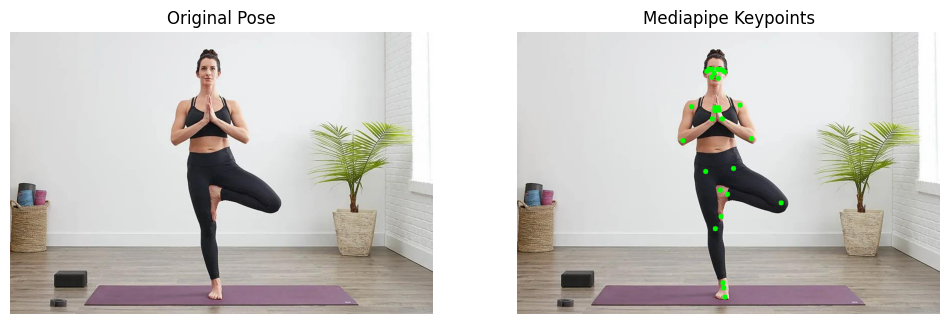

In [27]:
import cv2
import matplotlib.pyplot as plt
from mediapipe.tasks import python
from mediapipe.tasks.python import vision
import os
import urllib.request

# -----------------------------
# 1. Image path
# -----------------------------
image_path = "images/tree.jpeg"  # Replace with your image name
img = cv2.imread(image_path)
if img is None:
    raise FileNotFoundError(f"Image not found at {image_path}")

# -----------------------------
# 2. Pose Landmarker model
# -----------------------------
model_path = "pose_landmarker_heavy.task"
if not os.path.exists(model_path):
    url = "https://storage.googleapis.com/mediapipe-models/pose_landmarker/pose_landmarker_heavy/float16/1/pose_landmarker_heavy.task"
    print("Downloading Pose Landmarker model...")
    urllib.request.urlretrieve(url, model_path)
    print("Download complete!")

# -----------------------------
# 3. Initialize PoseLandmarker
# -----------------------------
base_options = python.BaseOptions(model_asset_path=model_path)
pose_options = vision.PoseLandmarkerOptions(base_options=base_options)
pose_detector = vision.PoseLandmarker.create_from_options(pose_options)

# -----------------------------
# 4. Prepare Mediapipe image
# -----------------------------
mp_image = mp.Image(image_format=mp.ImageFormat.SRGB, data=cv2.cvtColor(img, cv2.COLOR_BGR2RGB))

# -----------------------------
# 5. Detect landmarks
# -----------------------------
results = pose_detector.detect(mp_image)

# -----------------------------
# 6. Draw green keypoints
# -----------------------------
img_with_keypoints = img.copy()
if results.pose_landmarks:
    first_person_landmarks = results.pose_landmarks[0]
    h, w, _ = img_with_keypoints.shape
    for lm in first_person_landmarks:
        cx, cy = int(lm.x * w), int(lm.y * h)
        cv2.circle(img_with_keypoints, (cx, cy), 5, (0, 255, 0), -1)  # Green dot
else:
    print("No pose landmarks detected!")

# -----------------------------
# 7. Display side by side
# -----------------------------
plt.figure(figsize=[12,6])

plt.subplot(1,2,1)
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.title("Original Pose")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(cv2.cvtColor(img_with_keypoints, cv2.COLOR_BGR2RGB))
plt.title("Mediapipe Keypoints")
plt.axis("off")

plt.show()



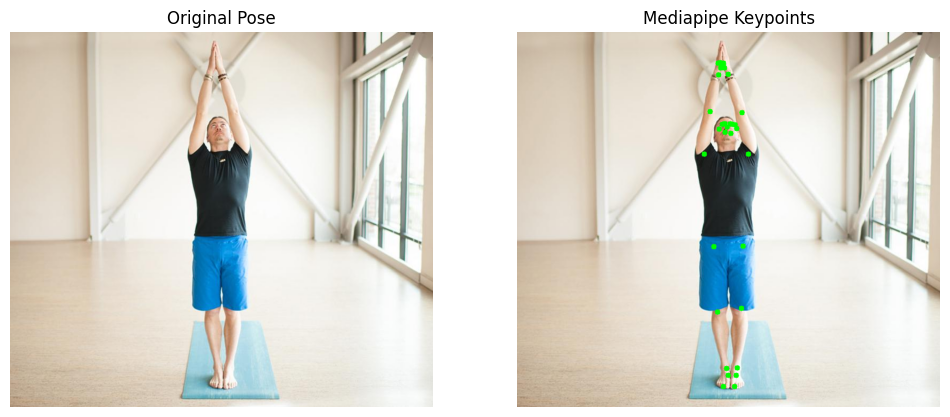

In [28]:
import cv2
import matplotlib.pyplot as plt
from mediapipe.tasks import python
from mediapipe.tasks.python import vision
import os
import urllib.request

# -----------------------------
# 1. Image path
# -----------------------------
image_path = "images/mountain.jpeg"  # Replace with your image name
img = cv2.imread(image_path)
if img is None:
    raise FileNotFoundError(f"Image not found at {image_path}")

# -----------------------------
# 2. Pose Landmarker model
# -----------------------------
model_path = "pose_landmarker_heavy.task"
if not os.path.exists(model_path):
    url = "https://storage.googleapis.com/mediapipe-models/pose_landmarker/pose_landmarker_heavy/float16/1/pose_landmarker_heavy.task"
    print("Downloading Pose Landmarker model...")
    urllib.request.urlretrieve(url, model_path)
    print("Download complete!")

# -----------------------------
# 3. Initialize PoseLandmarker
# -----------------------------
base_options = python.BaseOptions(model_asset_path=model_path)
pose_options = vision.PoseLandmarkerOptions(base_options=base_options)
pose_detector = vision.PoseLandmarker.create_from_options(pose_options)

# -----------------------------
# 4. Prepare Mediapipe image
# -----------------------------
mp_image = mp.Image(image_format=mp.ImageFormat.SRGB, data=cv2.cvtColor(img, cv2.COLOR_BGR2RGB))

# -----------------------------
# 5. Detect landmarks
# -----------------------------
results = pose_detector.detect(mp_image)

# -----------------------------
# 6. Draw green keypoints
# -----------------------------
img_with_keypoints = img.copy()
if results.pose_landmarks:
    first_person_landmarks = results.pose_landmarks[0]
    h, w, _ = img_with_keypoints.shape
    for lm in first_person_landmarks:
        cx, cy = int(lm.x * w), int(lm.y * h)
        cv2.circle(img_with_keypoints, (cx, cy), 5, (0, 255, 0), -1)  # Green dot
else:
    print("No pose landmarks detected!")

# -----------------------------
# 7. Display side by side
# -----------------------------
plt.figure(figsize=[12,6])

plt.subplot(1,2,1)
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.title("Original Pose")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(cv2.cvtColor(img_with_keypoints, cv2.COLOR_BGR2RGB))
plt.title("Mediapipe Keypoints")
plt.axis("off")

plt.show()


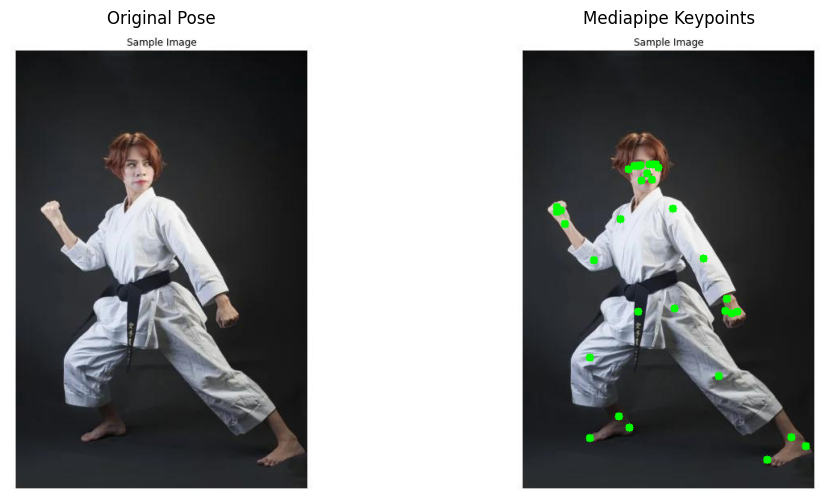

In [29]:
import cv2
import matplotlib.pyplot as plt
from mediapipe.tasks import python
from mediapipe.tasks.python import vision
import os
import urllib.request

# -----------------------------
# 1. Image path
# -----------------------------
image_path = "images/warrior.jpeg"  # Replace with your image name
img = cv2.imread(image_path)
if img is None:
    raise FileNotFoundError(f"Image not found at {image_path}")

# -----------------------------
# 2. Pose Landmarker model
# -----------------------------
model_path = "pose_landmarker_heavy.task"
if not os.path.exists(model_path):
    url = "https://storage.googleapis.com/mediapipe-models/pose_landmarker/pose_landmarker_heavy/float16/1/pose_landmarker_heavy.task"
    print("Downloading Pose Landmarker model...")
    urllib.request.urlretrieve(url, model_path)
    print("Download complete!")

# -----------------------------
# 3. Initialize PoseLandmarker
# -----------------------------
base_options = python.BaseOptions(model_asset_path=model_path)
pose_options = vision.PoseLandmarkerOptions(base_options=base_options)
pose_detector = vision.PoseLandmarker.create_from_options(pose_options)

# -----------------------------
# 4. Prepare Mediapipe image
# -----------------------------
mp_image = mp.Image(image_format=mp.ImageFormat.SRGB, data=cv2.cvtColor(img, cv2.COLOR_BGR2RGB))

# -----------------------------
# 5. Detect landmarks
# -----------------------------
results = pose_detector.detect(mp_image)

# -----------------------------
# 6. Draw green keypoints
# -----------------------------
img_with_keypoints = img.copy()
if results.pose_landmarks:
    first_person_landmarks = results.pose_landmarks[0]
    h, w, _ = img_with_keypoints.shape
    for lm in first_person_landmarks:
        cx, cy = int(lm.x * w), int(lm.y * h)
        cv2.circle(img_with_keypoints, (cx, cy), 5, (0, 255, 0), -1)  # Green dot
else:
    print("No pose landmarks detected!")

# -----------------------------
# 7. Display side by side
# -----------------------------
plt.figure(figsize=[12,6])

plt.subplot(1,2,1)
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.title("Original Pose")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(cv2.cvtColor(img_with_keypoints, cv2.COLOR_BGR2RGB))
plt.title("Mediapipe Keypoints")
plt.axis("off")

plt.show()


In [38]:
pip install pandas


   ---------------------------------------- 0.0/11.3 MB ? eta -:--:--
   ----- ---------------------------------- 1.6/11.3 MB 10.5 MB/s eta 0:00:01
   ------------- -------------------------- 3.9/11.3 MB 10.7 MB/s eta 0:00:01
   ----------------------- ---------------- 6.6/11.3 MB 11.2 MB/s eta 0:00:01
   ------------------------------- -------- 8.9/11.3 MB 11.3 MB/s eta 0:00:01
   ---------------------------------------  11.3/11.3 MB 11.4 MB/s eta 0:00:01
   ---------------------------------------- 11.3/11.3 MB 10.9 MB/s  0:00:01

   ---------------------------------------- 0/3 [pytz]
   ---------------------------------------- 0/3 [pytz]
   ------------- -------------------------- 1/3 [tzdata]
   ------------- -------------------------- 1/3 [tzdata]
   ------------- -------------------------- 1/3 [tzdata]
   -------------------------- ------------- 2/3 [pandas]
   -------------------------- ------------- 2/3 [pandas]
   -------------------------- ------------- 2/3 [pandas]
   -------

In [40]:
import cv2
import os
import numpy as np
from mediapipe.tasks.python import vision
from mediapipe.tasks import python
import matplotlib.pyplot as plt
import urllib.request
import pandas as pd

# -----------------------------
# 1. Model setup
# -----------------------------
model_path = "pose_landmarker_heavy.task"
if not os.path.exists(model_path):
    url = "https://storage.googleapis.com/mediapipe-models/pose_landmarker/pose_landmarker_heavy/float16/1/pose_landmarker_heavy.task"
    print("Downloading Pose Landmarker model...")
    urllib.request.urlretrieve(url, model_path)
    print("Download complete!")

base_options = python.BaseOptions(model_asset_path=model_path)
pose_options = vision.PoseLandmarkerOptions(base_options=base_options)
pose_detector = vision.PoseLandmarker.create_from_options(pose_options)

# -----------------------------
# 2. Folder with images
# -----------------------------
image_folder = "images"

# -----------------------------
# 3. Store results
# -----------------------------
results_list = []

for image_file in os.listdir(image_folder):
    if image_file.lower().endswith(('.jpeg', '.png', '.webp')):
        image_path = os.path.join(image_folder, image_file)
        img = cv2.imread(image_path)
        if img is None:
            print(f"Failed to load {image_file}")
            continue

        # Convert to Mediapipe format
        mp_image = mp.Image(image_format=mp.ImageFormat.SRGB, data=cv2.cvtColor(img, cv2.COLOR_BGR2RGB))

        # Detect pose
        detection_result = pose_detector.detect(mp_image)

        # Calculate confidence
        confidence_score = 0.0
        if detection_result.pose_landmarks:
            landmarks = detection_result.pose_landmarks[0]
            visibilities = [lm.visibility for lm in landmarks]
            if visibilities:
                confidence_score = np.mean(visibilities)

        # Extract pose name from filename
        pose_name = ''.join([c for c in image_file.split('.')[0] if not c.isdigit()]).capitalize()

        # Append to results
        results_list.append([image_file, pose_name, round(confidence_score,2)])

# -----------------------------
# 4. Display full table
# -----------------------------
df = pd.DataFrame(results_list, columns=["Image", "Pose", "Confidence Score"])
print(df)


           Image      Pose  Confidence Score
0  mountain.jpeg  Mountain              0.61
1      tree.jpeg      Tree              0.95
2   warrior.jpeg   Warrior              0.99


In [31]:
import cv2
import mediapipe as mp
import matplotlib.pyplot as plt

def detectPose(image, pose_detector, display=True):
    '''
    This function performs pose detection on an image using the Mediapipe Tasks API.
    Args:
        image: The input image with a prominent person whose pose landmarks needs to be detected.
        pose_detector: An initialized mediapipe.tasks.python.vision.PoseLandmarker object.
        display: A boolean value that is if set to true the function displays the original input image, the resultant image.
    Returns:
        output_image: The input image with the detected pose landmarks drawn.
        landmarks: A list of detected landmarks converted into their original scale.
    '''

    # Create a copy of the input image.
    output_image = image.copy()

    # Convert the image from BGR into RGB format for MediaPipe.
    mp_image = mp.Image(image_format=mp.ImageFormat.SRGB, data=cv2.cvtColor(image, cv2.COLOR_BGR2RGB))

    # Perform the Pose Detection.
    detection_result = pose_detector.detect(mp_image)

    # Retrieve the height and width of the input image.
    height, width, _ = image.shape

    # Initialize a list to store the detected landmarks.
    landmarks_list = []

    # Check if any landmarks are detected.
    if detection_result.pose_landmarks:
        # Assuming one person, get the first set of landmarks
        current_pose_landmarks = detection_result.pose_landmarks[0]

        # Draw Pose landmarks on the output image manually.
        for landmark in current_pose_landmarks:
            # Convert normalized coordinates to pixel coordinates
            x = int(landmark.x * width)
            y = int(landmark.y * height)

            # Draw a circle for each landmark
            cv2.circle(output_image, (x, y), 5, (0, 255, 0), -1) # Green circle, filled

            # Append the landmark (scaled to original image size) into the list.
            landmarks_list.append((x, y, landmark.z * width))

    # Check if the original input image and the resultant image are specified to be displayed.
    if display:
        # Display the original input image and the resultant image.
        plt.figure(figsize=[22,22])
        plt.subplot(121);plt.imshow(image[:,:,::-1]);plt.title("Original Image");plt.axis('off');
        plt.subplot(122);plt.imshow(output_image[:,:,::-1]);plt.title("Output Image");plt.axis('off');
        plt.show()

    # Otherwise
    else:
        # Return the output image and the found landmarks.
        return output_image, landmarks_list

In [ ]:
# Setup Pose function for video.
pose_video = mp_pose.Pose(static_image_mode=False, min_detection_confidence=0.5, model_complexity=1)

# Initialize the VideoCapture object to read from the webcam.
#video = cv2.VideoCapture(0)

# Initialize the VideoCapture object to read from a video stored in the disk.
video = cv2.VideoCapture('media/running.mp4')


# Initialize a variable to store the time of the previous frame.
time1 = 0

# Iterate until the video is accessed successfully.
while video.isOpened():

    # Read a frame.
    ok, frame = video.read()

    # Check if frame is not read properly.
    if not ok:

        # Break the loop.
        break

    # Flip the frame horizontally for natural (selfie-view) visualization.
    frame = cv2.flip(frame, 1)

    # Get the width and height of the frame
    frame_height, frame_width, _ =  frame.shape

    # Resize the frame while keeping the aspect ratio.
    frame = cv2.resize(frame, (int(frame_width * (640 / frame_height)), 640))

    # Perform Pose landmark detection.
    frame, _ = detectPose(frame, pose_video, display=False)

    # Set the time for this frame to the current time.
    time2 = time()

    # Check if the difference between the previous and this frame time > 0 to avoid division by zero.
    if (time2 - time1) > 0:

        # Calculate the number of frames per second.
        frames_per_second = 1.0 / (time2 - time1)

        # Write the calculated number of frames per second on the frame.
        cv2.putText(frame, 'FPS: {}'.format(int(frames_per_second)), (10, 30),cv2.FONT_HERSHEY_PLAIN, 2, (0, 255, 0), 3)

    # Update the previous frame time to this frame time.
    # As this frame will become previous frame in next iteration.
    time1 = time2

    # Display the frame.
    cv2.imshow('Pose Detection', frame)

    # Wait until a key is pressed.
    # Retreive the ASCII code of the key pressed
    k = cv2.waitKey(1) & 0xFF

    # Check if 'ESC' is pressed.
    if(k == 27):

        # Break the loop.
        break

# Release the VideoCapture object.
video.release()

# Close the windows.
cv2.destroyAllWindows()